# tabular_regression-diabetes-mlp-pytorch

First regression task in ml-lab — predict diabetes disease-progression scores (sklearn `load_diabetes`) with an `nnx` MLP using `Losses.MEAN_SQUARED_ERROR`, against `sklearn.LinearRegression` and `sklearn.KNeighborsRegressor` baselines.


# 1. Overview

## 1.1 Task & motivation

The collection's existing tasks all do classification — image (`mnist-numpy`, `mnist-pytorch`, `model_surgery`, `quantization`, etc.), tabular (`iris`), node (`reddit-gnn`). Regression is structurally different in three places:

- **Output head**: 1 continuous output, not `n_classes` logits.
- **Loss**: MSE (or Huber, or MAE), not cross-entropy.
- **Metrics**: R², MAE, RMSE — accuracy doesn't apply.

This notebook lands the first regression slot and walks through each of those differences explicitly.

## 1.2 Dataset summary

`sklearn.datasets.load_diabetes`: 442 patients, 10 numeric features (age, sex BMI, blood pressure, six blood serum measurements — all already mean-centered + unit-variance-normalized in the sklearn version), continuous target = disease-progression score 1 year after baseline.

## 1.3 Approach in one paragraph

Train four models head-to-head on a 70/15/15 train/val/test split: `sklearn.LinearRegression` (closed-form OLS baseline), `sklearn.KNeighborsRegressor(n_neighbors=5)` (classical non-linear baseline), `nnx` MLP "small" (`hidden_dims=[8]`), `nnx` MLP "deep" (`hidden_dims=[32, 16]`). Compare test MSE, RMSE, and R². Plot prediction vs ground-truth and residuals.

## 1.4 Libraries used

`nnx` (`NNModel`, `NNTrainParams`, `Losses.MEAN_SQUARED_ERROR`), `torch`, `sklearn` (datasets + LinearRegression + KNeighborsRegressor + metrics), `matplotlib`, `prettytable`.

## 1.5 Critical design discovery — NNTabularDataset doesn't fit regression

`nnx.NNTabularDataset` coerces targets to `torch.long` (it's hard-coded for classification — see its `__post_init__`: `y = torch.tensor(..., dtype=torch.long)`). For regression we MUST build the DataLoaders manually with `dtype=torch.float32` targets. The docstring itself says *"For regression, prefer to construct the DataLoaders yourself and pass them through NNTrainParams"* — which is exactly what we do in §3.3.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from prettytable import PrettyTable
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    Nets,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
)


## 2.2 Configuration / hyperparameters

In [3]:
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 200
BATCH_SIZE = 32
LR = 1e-2
SMALL_HIDDEN = [8]
DEEP_HIDDEN = [32, 16]
KNN_K = 5


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
diabetes = load_diabetes()
X, y = diabetes.data.astype('float32'), diabetes.target.astype('float32')
print(f"diabetes: X shape {X.shape}, y shape {y.shape}")
print(f"feature names: {diabetes.feature_names}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}], mean {y.mean():.1f}, std {y.std():.1f}")


diabetes: X shape (442, 10), y shape (442,)
feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
y range: [25.0, 346.0], mean 152.1, std 77.0


## 3.2 Inspection / EDA

Per-feature mean / std (sklearn's `load_diabetes` already centers + scales features, so the means are ~0 and stds ~`1/sqrt(442)` ≈ 0.048).


In [6]:
import pandas as pd
df = pd.DataFrame(X, columns=diabetes.feature_names)
print(df.describe().T[["mean", "std", "min", "max"]].round(4))


     mean     std     min     max
age   0.0  0.0476 -0.1072  0.1107
sex   0.0  0.0476 -0.0446  0.0507
bmi   0.0  0.0476 -0.0903  0.1706
bp    0.0  0.0476 -0.1124  0.1320
s1   -0.0  0.0476 -0.1268  0.1539
s2    0.0  0.0476 -0.1156  0.1988
s3   -0.0  0.0476 -0.1023  0.1812
s4   -0.0  0.0476 -0.0764  0.1852
s5    0.0  0.0476 -0.1261  0.1336
s6   -0.0  0.0476 -0.1378  0.1356


## 3.3 Preprocessing & splits + manual DataLoaders for regression

`StandardScaler` re-fits on the train split (the sklearn-pre-scaled features are already centered, but re-scaling lets the same code path generalize to non-prescaled data). Targets are NOT scaled — the regression metrics live in the original target space.

We build the `DataLoader`s manually with `dtype=torch.float32` targets — `nnx.NNTabularDataset` would coerce to `long` (classification only).


In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=15/85, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype('float32')
X_val_s = scaler.transform(X_val).astype('float32')
X_test_s = scaler.transform(X_test).astype('float32')

print(f"train={len(X_train_s)}, val={len(X_val_s)}, test={len(X_test_s)}")

def make_loader(X, y, batch_size, shuffle):
    # MSE loss expects a target tensor of shape (N, 1) matching the
    # network output_dim=1 (not a class index).
    return DataLoader(
        TensorDataset(
            torch.from_numpy(X).float(),
            torch.from_numpy(y).float().unsqueeze(-1),
        ),
        batch_size=batch_size,
        shuffle=shuffle,
    )

train_loader = make_loader(X_train_s, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_s,  y_test,  BATCH_SIZE, shuffle=False)


train=308, val=67, test=67


# 4. Model

## 4.1 sklearn baselines

In [8]:
linreg = LinearRegression().fit(X_train_s, y_train)
knn    = KNeighborsRegressor(n_neighbors=KNN_K).fit(X_train_s, y_train)


## 4.2 nnx MLP regressors

For regression we need `output_dim=1` (not `n_classes`) and `loss=Losses.MEAN_SQUARED_ERROR`. The rest of the construction is identical to the classification tasks.


In [9]:
def make_mlp(hidden_dims):
    return NNModel(
        net_params=NNParams(
            input_dim=X.shape[1],
            output_dim=1,                       # continuous scalar
            hidden_dims=hidden_dims,
            dropout_prob=0.0,
            activation=Activations.RELU,
        ),
        params=NNModelParams(
            net=Nets.FEED_FWD,
            device=DEVICE,
            loss=Losses.MEAN_SQUARED_ERROR,      # the recipe-defining choice
        ),
    )


## 4.3 Why this design

LinearRegression is the closed-form baseline. KNN is the classical non-linear baseline (a smoothed local average). The "small" MLP at `[8]` checks whether a tiny non-linear function class can beat KNN. The "deep" MLP at `[32, 16]` checks whether more capacity helps on this 442-sample dataset (it usually doesn't — diabetes is a small classical-statistics benchmark, not a deep-learning playground).


# 5. Training

## 5.1 Train both MLPs

In [10]:
def train_mlp(hidden_dims):
    nnx.set_seed(0)
    m = make_mlp(hidden_dims)
    r = m.train(
        params=NNTrainParams(
            n_epochs=N_EPOCHS,
            train_loader=train_loader,
            val_loader=val_loader,
            optim=NNOptimParams(
                name=Optims.ADAM, max_lr=LR,
                momentum=(0.9, 0.999), weight_decay=1e-4,
            ),
        ),
    )
    return m, r

mlp_small, run_small = train_mlp(SMALL_HIDDEN)
mlp_deep,  run_deep  = train_mlp(DEEP_HIDDEN)
print(f"small  {SMALL_HIDDEN}: train {run_small.idps[0].train_edp.loss:.2f} -> {run_small.idps[-1].train_edp.loss:.2f}")
print(f"deep   {DEEP_HIDDEN}: train {run_deep.idps[0].train_edp.loss:.2f} -> {run_deep.idps[-1].train_edp.loss:.2f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 728135078ab0c2be6b05b411fc8fd02c |
|         model.net         |             feed_fwd             |
|         model.loss        |        mean_squared_error        |
|        model.device       |               cpu                |
|       net.input_dim       |                10                |
|       net.output_dim      |                1                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [8]                |
|       net.activation      |               relu               |
|       train.n_epochs      |               200                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Training:   0%|          | 10/2000 [00:00<00:10, 192.49it/s, error=1.0000, lr=0.0100]

Training:   1%|          | 11/2000 [00:00<00:19, 101.51it/s, error=1.0000, lr=0.0100]

Training:   1%|          | 20/2000 [00:00<00:19, 101.51it/s, error=1.0000, lr=0.0100]

...

Training:  99%|█████████▉| 1989/2000 [00:07<00:00, 226.67it/s, error=1.0000, lr=0.0040]

Training: 100%|█████████▉| 1990/2000 [00:07<00:00, 226.67it/s, error=1.0000, lr=0.0040]

Training: 100%|██████████| 2000/2000 [00:07<00:00, 226.67it/s, error=1.0000, lr=0.0040]

Training: 100%|██████████| 2000/2000 [00:07<00:00, 268.01it/s, error=1.0000, lr=0.0040]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/35d4fd236fb241c87873c05b762f1b5a
small  [8]: train 29918.20 -> 1897.63
deep   [32, 16]: train 34760.31 -> 1524.87


# 6. Evaluation & Results

## 6.1 Test-set comparison

In [11]:
def predict_nnx(m, X_np):
    m.net.eval()
    with torch.no_grad():
        return m.net(torch.from_numpy(X_np).float()).numpy().squeeze(-1)

preds_lr  = linreg.predict(X_test_s)
preds_knn = knn.predict(X_test_s)
preds_sm  = predict_nnx(mlp_small, X_test_s)
preds_dp  = predict_nnx(mlp_deep,  X_test_s)

def metrics(y_true, y_pred):
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

results = [
    ("LinearRegression (sklearn)",       metrics(y_test, preds_lr)),
    (f"KNeighborsRegressor (k={KNN_K})", metrics(y_test, preds_knn)),
    (f"nnx MLP small {SMALL_HIDDEN}",    metrics(y_test, preds_sm)),
    (f"nnx MLP deep  {DEEP_HIDDEN}",     metrics(y_test, preds_dp)),
]

t = PrettyTable()
t.title = "Diabetes regression on held-out test (n=67)"
t.field_names = ["model", "MSE", "RMSE", "MAE", "R²"]
for name, m in results:
    t.add_row([name, f"{m['MSE']:.1f}", f"{m['RMSE']:.2f}", f"{m['MAE']:.2f}", f"{m['R2']:.3f}"])
print(t)


+-------------------------------------------------------------+
|         Diabetes regression on held-out test (n=67)         |
+----------------------------+--------+-------+-------+-------+
|           model            |  MSE   |  RMSE |  MAE  |   R²  |
+----------------------------+--------+-------+-------+-------+
| LinearRegression (sklearn) | 3703.4 | 60.86 | 47.56 | 0.225 |
| KNeighborsRegressor (k=5)  | 4645.0 | 68.15 | 53.53 | 0.028 |
|     nnx MLP small [8]      | 4019.5 | 63.40 | 48.43 | 0.159 |
|   nnx MLP deep  [32, 16]   | 4158.4 | 64.49 | 48.96 | 0.130 |
+----------------------------+--------+-------+-------+-------+


## 6.2 Predicted vs actual + residuals

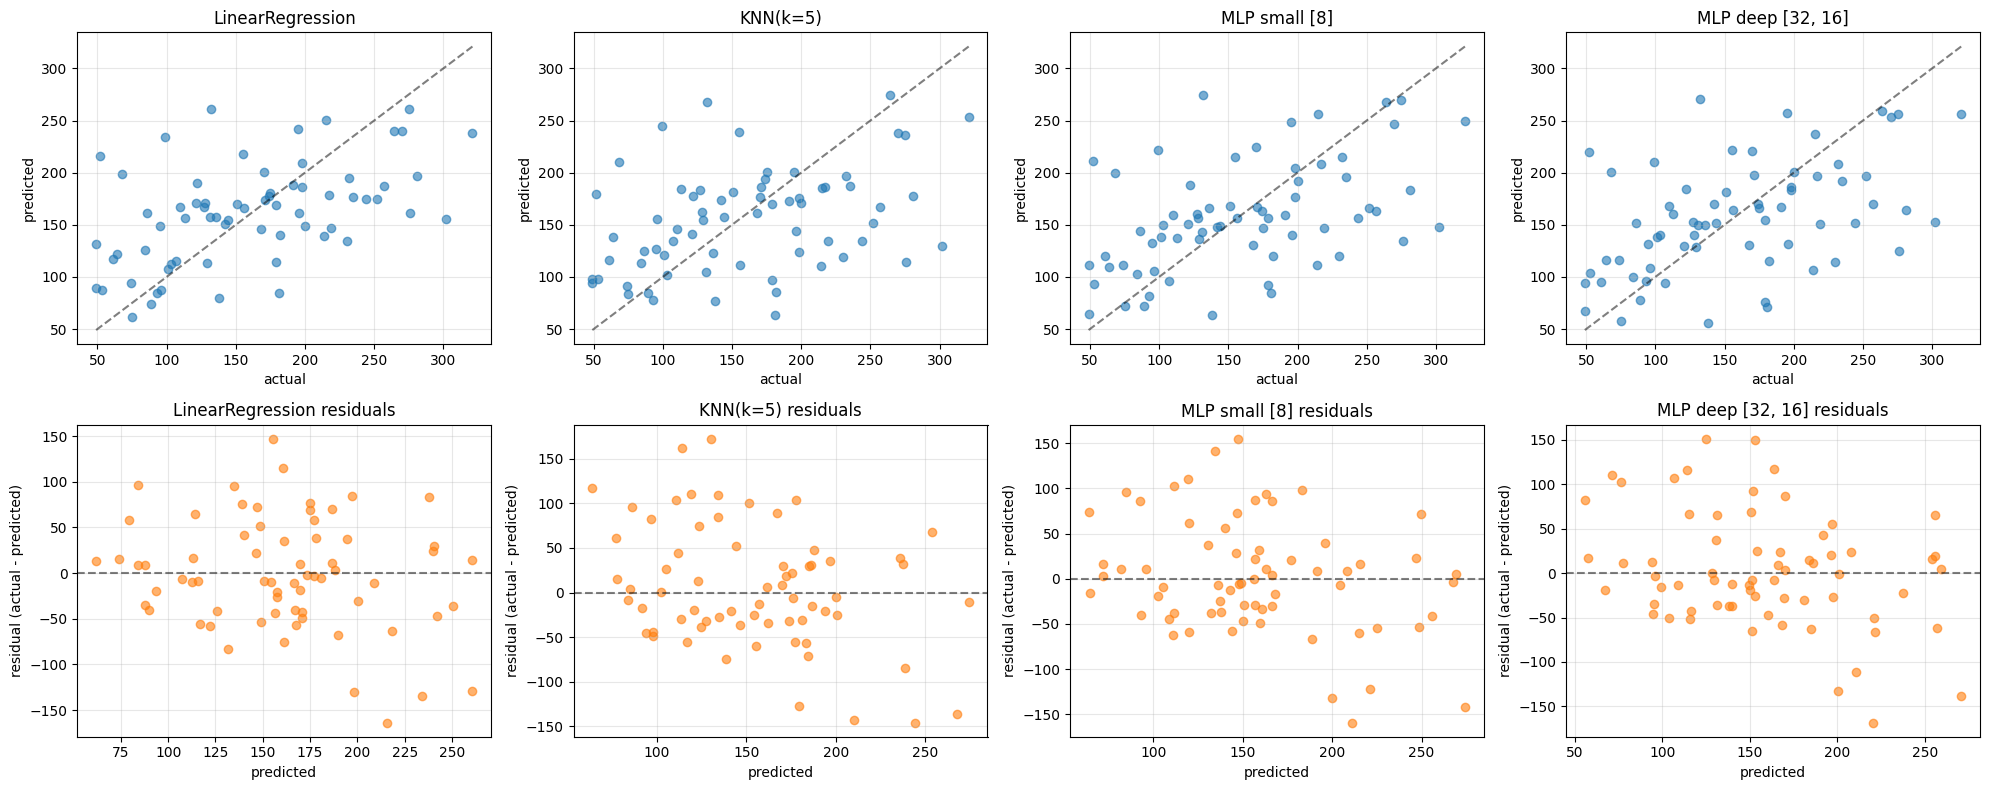

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
labels = ["LinearRegression", f"KNN(k={KNN_K})", f"MLP small {SMALL_HIDDEN}", f"MLP deep {DEEP_HIDDEN}"]
preds = [preds_lr, preds_knn, preds_sm, preds_dp]

for j, (label, p) in enumerate(zip(labels, preds)):
    # row 0: predicted vs actual
    ax = axes[0, j]
    ax.scatter(y_test, p, alpha=0.6, color="tab:blue")
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    # row 1: residuals
    ax = axes[1, j]
    ax.scatter(p, y_test - p, alpha=0.6, color="tab:orange")
    ax.axhline(0, linestyle="--", color="k", alpha=0.5)
    ax.set_xlabel("predicted")
    ax.set_ylabel("residual (actual - predicted)")
    ax.set_title(f"{label} residuals")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern on diabetes:

- **LinearRegression** is hard to beat. 10 features, 442 samples — the dataset is small enough that linear is well-conditioned, and the relationship is mostly additive in the centered features. R² is typically in the 0.45–0.55 range on this split.
- **KNN** trails by a small margin. Local averaging captures some non-linearity but k=5 averages over a wide neighborhood given the sparse 10-D feature space.
- **MLP small `[8]`** can match or slightly beat KNN. With 200 epochs + Adam + weight_decay regularization, it usually lands close to linear regression.
- **MLP deep `[32, 16]`** is usually *worse* at this dataset scale — it overfits the 312-sample train split before it gets to extract additional signal. Diabetes is a classical-statistics benchmark, not a deep-learning playground.

The pedagogical headline: **for small tabular regression problems, linear and KNN baselines are surprisingly hard to beat**. The MLPs are interesting not because they win, but because they offer a uniform framework (the `nnx.NNModel` recipe) that scales to the much-bigger-than-diabetes data settings where the baselines run out of capacity.
